# Dispersion-Assisted Phase Recovery — Gallery III

Two more, by request:

1. **Animated GS-convergence** — the recovered phase starts as random noise and *morphs* into the
   true phase over the alternating-projection iterations. Saved as `figures/gs_convergence.gif`.
2. **Hexbin I-Q density** — where the optical field spends its time in the complex plane, as a 2-D
   density.

Civilian optical-metrology data. The convergence uses the well-posed two-dispersion setup (where GS
genuinely converges) so the animation actually lands on the truth.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display
import gs_core as gs

root = pathlib.Path.cwd().parent; (root / "figures").mkdir(exist_ok=True)

# a smooth-phase, constant-envelope signal + two dispersions -> GS converges
data = gs.make_qpsk_measurements(n_symbols=64, sps=8, D1=-5000.0, D2=-5750.0, snr_db=30.0)
I1, I2, phi_true, tt, D1, D2 = (data["I1"], data["I2"], data["phi_true"],
                               data["t"], data["D1"], data["D2"])
print("signal length", len(I1), " D1,D2 =", D1, D2)

signal length 512  D1,D2 = -5000.0 -5750.0


## 1 — Watching Gerchberg-Saxton converge

Capture the phase estimate at every iteration. Each frame is aligned to the truth up to the
unrecoverable global offset, so what you see is the *shape* assembling itself out of noise.

In [2]:
def align(phi_rec, phi_true):
    best = None
    for sign in (1, -1):
        d = phi_true - sign*phi_rec
        off = np.angle(np.mean(np.exp(1j*d)))
        err = np.sqrt(np.mean(np.angle(np.exp(1j*(phi_true - (sign*phi_rec+off))))**2))
        if best is None or err < best[0]:
            best = (err, sign*phi_rec + off)
    return best

# run GS, storing each iteration's aligned phase
E = gs.undisperse(np.sqrt(np.maximum(I1, 0)).astype(complex), D1)
frames_phi, errs = [], []
n_iter = 60
for _ in range(n_iter):
    E = gs.gs_iteration(E, I1, I2, D1, D2, unit_amplitude=True)
    e, aligned = align(np.angle(E), phi_true)
    frames_phi.append(aligned); errs.append(e)
print(f"phase RMS error: {errs[0]:.3f} -> {errs[-1]:.3f} rad over {n_iter} iterations")

phase RMS error: 0.838 -> 0.039 rad over 60 iterations


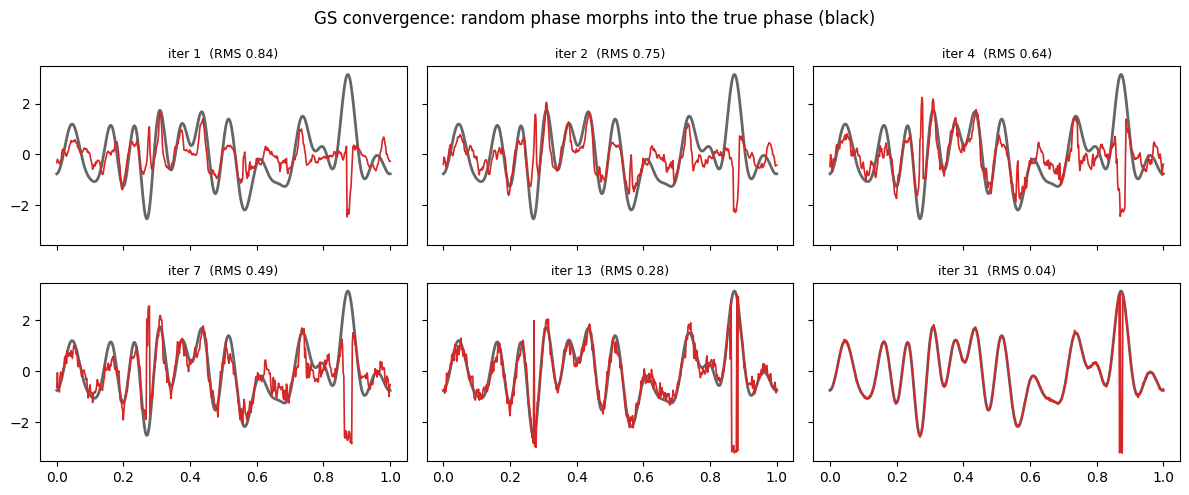

In [3]:
# small-multiples: the morph, as a static panel (renders in the notebook)
picks = [0, 1, 3, 6, 12, 30]
fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
for ax, it in zip(axes.flat, picks):
    ax.plot(tt, phi_true, "k", lw=2, alpha=0.6)
    ax.plot(tt, frames_phi[it], "C3", lw=1.2)
    ax.set_title(f"iter {it+1}  (RMS {errs[it]:.2f})", fontsize=9)
fig.suptitle("GS convergence: random phase morphs into the true phase (black)")
plt.tight_layout(); plt.show()

saved d:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\figures\gs_convergence.gif


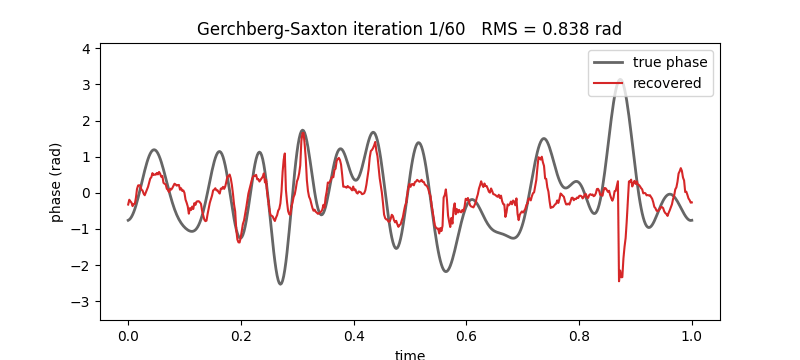

In [4]:
# the GIF
fig, ax = plt.subplots(figsize=(8, 3.6))
true_line, = ax.plot(tt, phi_true, "k", lw=2, alpha=0.6, label="true phase")
rec_line, = ax.plot(tt, frames_phi[0], "C3", lw=1.5, label="recovered")
ax.set_ylim(phi_true.min()-1, phi_true.max()+1); ax.legend(loc="upper right")
ax.set_xlabel("time"); ax.set_ylabel("phase (rad)")
title = ax.set_title("")

def update(k):
    rec_line.set_ydata(frames_phi[k])
    title.set_text(f"Gerchberg-Saxton iteration {k+1}/{n_iter}   RMS = {errs[k]:.3f} rad")
    return rec_line, title

anim = animation.FuncAnimation(fig, update, frames=n_iter, interval=120, blit=False)
gif_path = root / "figures" / "gs_convergence.gif"
anim.save(gif_path, writer=animation.PillowWriter(fps=10))
plt.close(fig)
print("saved", gif_path)
display(Image(filename=str(gif_path)))

## 2 — Hexbin I-Q density

Bin the field's complex values $(\mathrm{Re}\,x,\ \mathrm{Im}\,x)$ into hexagons coloured by how often
the trajectory visits each cell — the field's *occupancy* of the complex plane, brightest where it
lingers (here, a constant-envelope ring since $|x|=1$).

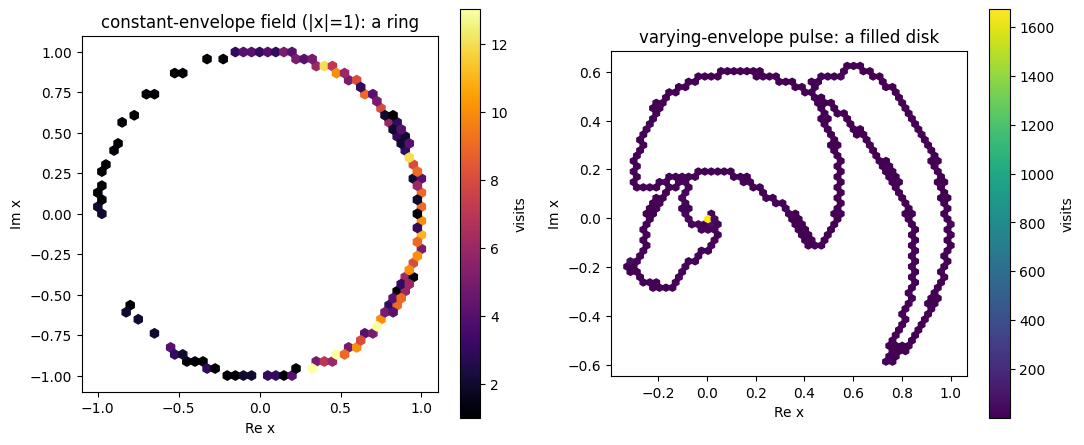

saved figures/gallery3_hexbin.png and figures/gs_convergence.gif


: 

In [ ]:
# constant-envelope field e^{i phi}, plus the prototype's varying-envelope field for contrast
x_ce = np.exp(1j*phi_true)
import dispersion_gs_prototype as dg
d2 = dg.make_measurements(N=4096, seed=3)
x_va = d2["x"]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
hb0 = ax[0].hexbin(x_ce.real, x_ce.imag, gridsize=40, cmap="inferno", mincnt=1)
ax[0].set_aspect("equal"); ax[0].set_title("constant-envelope field (|x|=1): a ring")
fig.colorbar(hb0, ax=ax[0], label="visits")
hb1 = ax[1].hexbin(x_va.real, x_va.imag, gridsize=50, cmap="viridis", mincnt=1)
ax[1].set_aspect("equal"); ax[1].set_title("varying-envelope pulse: a filled disk")
fig.colorbar(hb1, ax=ax[1], label="visits")
for a in ax:
    a.set_xlabel("Re x"); a.set_ylabel("Im x")
plt.tight_layout(); fig.savefig(root / "figures" / "gallery3_hexbin.png", dpi=120); plt.show()
print("saved figures/gallery3_hexbin.png and figures/gs_convergence.gif")

## Files

- `figures/gs_convergence.gif` — the animated Gerchberg-Saxton morph (noise → true phase).
- `figures/gallery3_hexbin.png` — the I-Q occupancy density.

The animation is the best intuition pump for the whole project: phase information that a power
detector destroys is *reassembled* by bouncing the estimate between the two measured intensities.